<font color="#0A1F44" face="sans-serif" size="7">
<b>Erika Shrestha</b>
</font>
<BR>
<font color="#0A1F44" face="sans-serif" size="4.5">
<b>London Met ID: 23048598</b>
</font>

---



<b>This project cluster nearby customer orders, enabling efficient bulk batching, optimized route planning and improved rider allocation in Q-Commerce. In addition to this, the project shows the comparision between K-Means, DBscan, and Hierarchical clustering to validate their adaptability and limitations.</b>

In [99]:
#INSTALL necessary librabries that are not by-default stored in colab
#!pip install -q datasets

---
---

# **IMPORTED LIBRARIES**

In [2]:
#IMPORT all the necessary libraries used in the project
#installed package is used here to load dataset
from datasets import load_dataset
#Data manipulation
import pandas as pd
#Numerical calc execution
import numpy as np
#Visualize with plots and graphs
import matplotlib.pyplot as plt
import seaborn as sns
#Scaling to avoid data dominance
from sklearn.preprocessing import StandardScaler
#Dimensionality reduction
from sklearn.decomposition import PCA
#Finds closest point in dataset
from sklearn.neighbors import NearestNeighbors
#Evaluate model performance
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
#Imports the first clustering candidate
from sklearn.cluster import KMeans
#Imports the second clustering candidate
from sklearn.cluster import DBSCAN
#USED to remove detected outliers
from scipy.stats import zscore
#Used for calculating pairwise distances
from scipy.spatial.distance import cdist
#Plot to find optimal parameter for hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
#Imports the third clustering candidate
from sklearn.cluster import AgglomerativeClustering
#Cuts threshold for hierarchical clustering
from scipy.cluster.hierarchy import fcluster
#Ignores the warnings
import warnings
warnings.filterwarnings("ignore")

---
---

# **HELPER METHODS**

In [3]:
#COMMON FUNCTION to calculate silhouette score for all clustering algorithm
def calculate_silhouette_score(X, labels):

  labels = np.array(labels)

  #REMOVES dbscan noises : -1
  X_valid = X[labels != -1]
  labels_valid = labels[labels != -1]

  if len(np.unique(labels_valid)) < 2:
      return None

  return silhouette_score(X_valid, labels_valid)

In [4]:
#COMMON FUNCTION to calculate Davies-Bouldin index for all clustering algorithm
def calculate_DBI(X, labels):
    labels = np.array(labels)

    #REMOVES dbscan noises : -1
    X_valid = X[labels != -1]
    labels_valid = labels[labels != -1]

    if len(np.unique(labels_valid)) < 2:
        return None

    return davies_bouldin_score(X_valid, labels_valid)

In [5]:
#COMMON FUNCTION to calculate calinski_harabasz_score for all clustering algorithm
def calculate_calinski_harabasz(X, labels):
    labels = np.array(labels)

    #REMOVES dbscan noises : -1
    X_valid = X[labels != -1]
    labels_valid = labels[labels != -1]

    if len(np.unique(labels_valid)) < 2:
        return None

    return calinski_harabasz_score(X_valid, labels_valid)

In [6]:
#FUNCTION to find the mode of feature
def most_common_value(column):
    return column.mode()[0]

---
---

# **TEMPORARY DATA LOAD**
This notebook is designed to be fully reproducible in Google Colab.
Please ensure the setup cells (necessary installation above) are run sequentially before executing the rest of the notebook.

In [7]:
#EXTRACTS dataset from the hugging face
dataset = load_dataset("Cainiao-AI/LaDe-D")

In [8]:
#FILTERS  and loads parquet file of 900K+ from the sets
delivery_cq = dataset["delivery_cq"]

In [9]:
#LOADS parquet file of 900K+ and CONVERTS to csv
delivery_cq.to_csv('Data/delivery_cq.csv')

Creating CSV from Arrow format:   0%|          | 0/932 [00:00<?, ?ba/s]

144414451

In [10]:
#STORES the loaded dataset to a pandas dataframe
chitto_yatra_df = pd.read_csv("Data/delivery_cq.csv")

In [11]:
#VIEWS dataframe
chitto_yatra_df

,order_id,region_id,city,courier_id,lng,lat,aoi_id,aoi_type,accept_time,accept_gps_time,accept_gps_lng,accept_gps_lat,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,ds
0,2031782,10,Chongqing,73,108.71571,30.90228,50,14,10-22 10:26:00,10-22 10:26:00,108.71826,30.95587,10-22 17:04:00,10-22 17:04:00,108.66361,30.96702,1022
1,4285071,10,Chongqing,3605,108.71639,30.90269,50,14,09-07 10:13:00,09-07 10:13:00,108.71791,30.95635,09-09 15:44:00,09-09 15:44:00,108.71644,30.90266,907
2,4056800,10,Chongqing,3605,108.71645,30.90259,50,14,06-26 09:49:00,06-26 09:49:00,108.71798,30.95635,06-27 16:03:00,06-27 16:03:00,108.71647,30.90251,626
3,3589481,10,Chongqing,3605,108.71650,30.90347,50,14,09-11 11:01:00,09-11 11:01:00,108.71823,30.95596,09-13 17:14:00,09-13 17:14:00,108.71650,30.90341,911
4,2752329,10,Chongqing,3605,108.71608,30.90409,50,14,10-01 09:52:00,10-01 09:52:00,108.71820,30.95598,10-01 18:30:00,10-01 18:30:00,108.71413,30.90397,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931346,408723,166,Chongqing,4855,106.48823,29.49533,60054,1,10-27 08:36:00,10-27 08:36:00,106.52756,29.49760,10-27 12:30:00,10-27 12:30:00,106.50547,29.49880,1027
931347,3133674,166,Chongqing,4855,106.48839,29.49522,60054,1,10-25 09:24:00,10-25 09:24:00,106.52752,29.49765,10-25 12:53:00,10-25 12:53:00,106.48840,29.49507,1025
931348,4469852,166,Chongqing,4855,106.48822,29.49530,60054,1,10-24 14:11:00,10-24 14:11:00,106.52755,29.49764,10-24 16:39:00,10-24 16:39:00,106.48843,29.49484,1024
931349,2140790,166,Chongqing,4855,106.48822,29.49537,60054,1,10-29 15:24:00,10-29 15:24:00,106.52746,29.49751,10-29 18:08:00,10-29 18:08:00,106.48854,29.49509,1029


---
---

# **EXPLORATORY DATA ANALYSIS (EDA)**

**The original delivery_cq dataset has shape of (931351,17). For understanding the characteristics of the datasets, large dataset is carefully examined.**

# **Data Quality Check**

1.   Missing Values vs Non-Missing Values Check
2.   Data Type Consistency
3.   Duplication Check
4.   Outlier Detection
5.   Multicollinearity Check

---

#####**1. Missing Values vs Non-Missing Values Check**

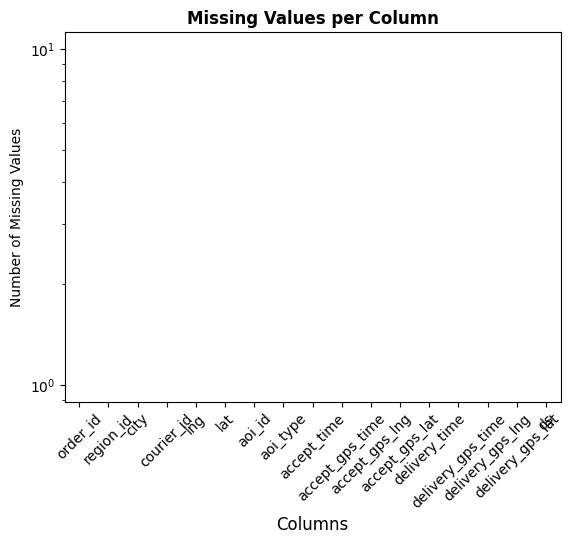

In [12]:
#DISPLAYS missing values for all features
missing_counts = chitto_yatra_df.isnull().sum()

plt.figure(figsize=(6.4, 4.8))
missing_counts.plot.bar(color='#90EE90', log=True)
plt.title("Missing Values per Column", fontweight='bold')
plt.ylabel("Number of Missing Values")
plt.xlabel('Columns', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [13]:
#CHECKS whether there is presence of high missing values (case = missing_values > 50%)
total_rows = len(chitto_yatra_df)
missing_percent_per_columns = ((missing_counts / total_rows) * 100).round(1)
missing_percent_per_columns

,0
order_id,0.0
region_id,0.0
city,0.0
courier_id,0.0
lng,0.0
lat,0.0
aoi_id,0.0
aoi_type,0.0
accept_time,0.0
accept_gps_time,0.0


**As shown in the figure, there is no presence of any missing values in any features which concludes that any column has not a single null value.**

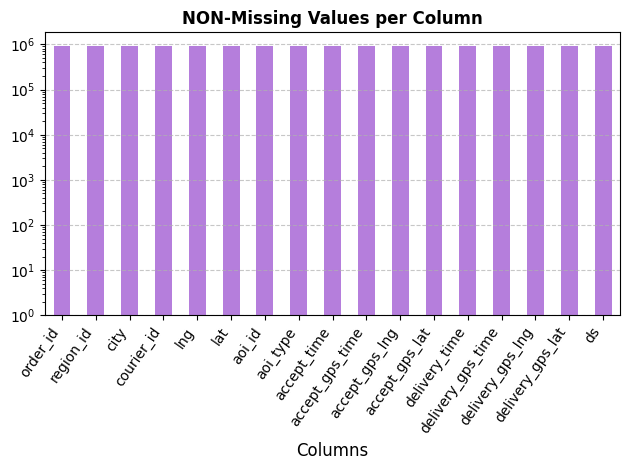

In [14]:
#DISPLAY each features row count
non_missing_counts = chitto_yatra_df.notnull().sum()

non_missing_counts.plot.bar(color='#B57EDC', log=True)
plt.title('NON-Missing Values per Column', fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.xticks(rotation=55, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Just to provide a confirmation and comparison, a figure with every features with all rows is plotted to do cross verification.**

---
---

#####**2. Data Type Consistency**

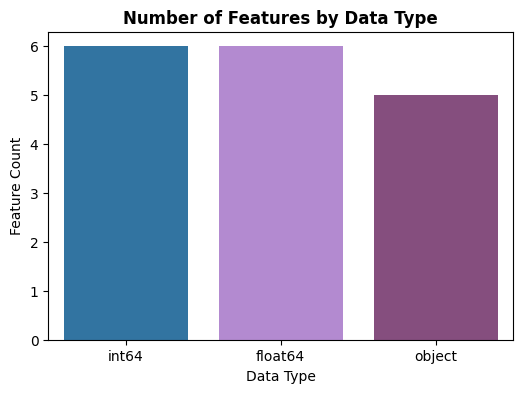

In [15]:
#CHECKS data types present in the dataset
dtype_counts = chitto_yatra_df.dtypes.value_counts()

colors = ['#1F77B4', '#B57EDC', '#8E4585']
plt.figure(figsize=(6,4))
sns.barplot(x=dtype_counts.index.astype(str), y=dtype_counts.values, palette=colors)
plt.title("Number of Features by Data Type", fontweight='bold')
plt.ylabel("Feature Count")
plt.xlabel("Data Type")
plt.show()

In [16]:
#GROUPS feature by their data types
features_by_dtype = chitto_yatra_df.columns.groupby(chitto_yatra_df.dtypes)
for dtype, features in features_by_dtype.items():
    print(f"\n\033[1m{dtype}:\033[0m")
    for col in features:
        print(f" - {col}")


int64:
 - order_id
 - region_id
 - courier_id
 - aoi_id
 - aoi_type
 - ds

float64:
 - lng
 - lat
 - accept_gps_lng
 - accept_gps_lat
 - delivery_gps_lng
 - delivery_gps_lat

object:
 - city
 - accept_time
 - accept_gps_time
 - delivery_time
 - delivery_gps_time


**There are 6 columns equally grouped to integer (64-bit) and float (64-bit) whereas the remaining 5 belongs to object (string) type.**

---
---

#####**3. Duplication Check**

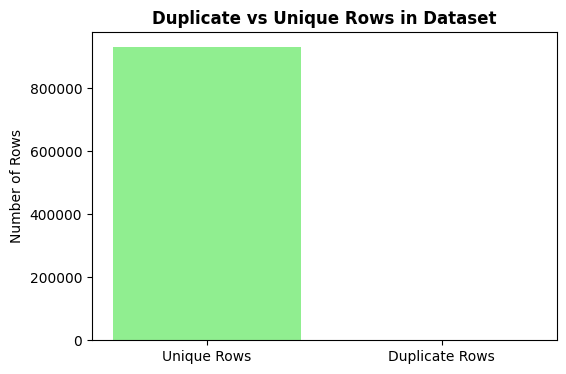

In [17]:
#CHECKS whether the dataset has any duplicate rows
duplicate_counts = chitto_yatra_df.duplicated().sum()
unique_count = len(chitto_yatra_df) - duplicate_counts

plt.figure(figsize=(6,4))
plt.bar(['Unique Rows', 'Duplicate Rows'], [unique_count, duplicate_counts],
        color=['lightgreen', 'skyblue'])
plt.title("Duplicate vs Unique Rows in Dataset", fontweight='bold')
plt.ylabel("Number of Rows")
plt.show()

**The dataset contains no duplicate rows. All rows are unique, ensuring that each observation is distinct and there is no redundant data.**

---
---

#####**4. Outlier Detection**

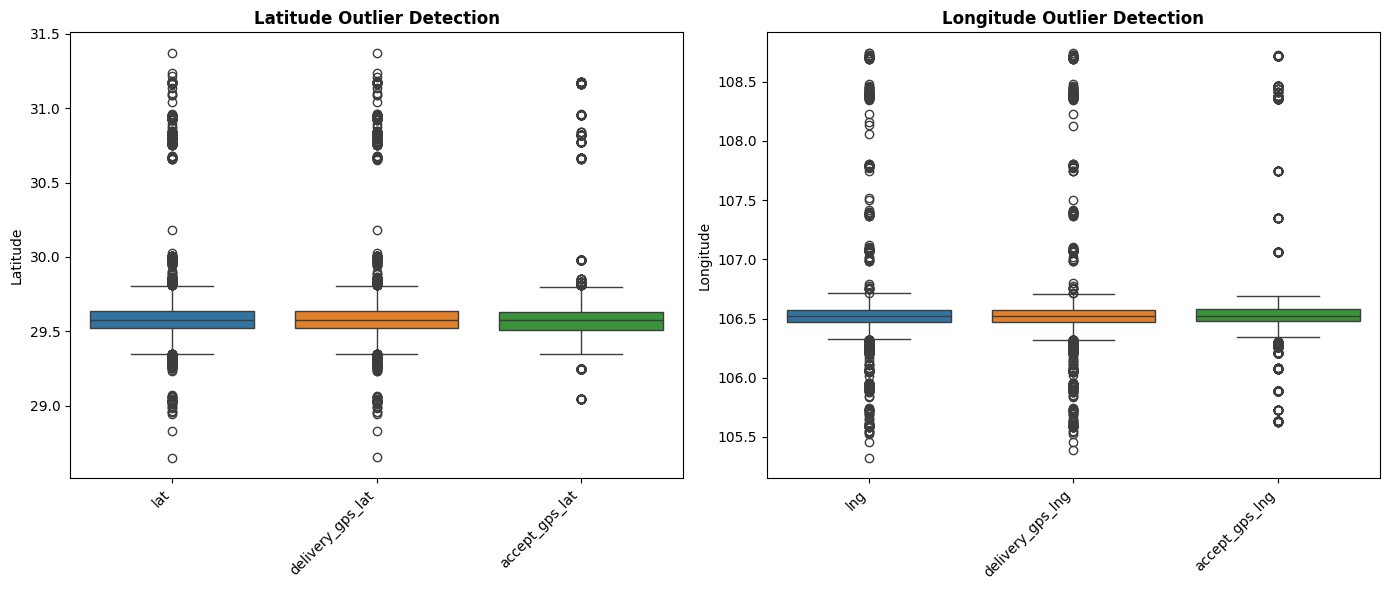

In [18]:
#CHECKS noises in the latitute-related and longitude-related columns
lat_cols = ['lat', 'delivery_gps_lat', 'accept_gps_lat']
lng_cols = ['lng', 'delivery_gps_lng', 'accept_gps_lng']

sample_df = chitto_yatra_df.sample(5000, random_state=42)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(data=sample_df[lat_cols])
plt.title("Latitude Outlier Detection", fontweight='bold')
plt.ylabel("Latitude")
plt.xticks(rotation=45, ha='right')

plt.subplot(1,2,2)
sns.boxplot(data=sample_df[lng_cols])
plt.title("Longitude Outlier Detection", fontweight='bold')
plt.ylabel("Longitude")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


**The boxplot reveal that accepted GPS coordinate appears more reliable and stable compared to the delivery gps in terms of both longitude and latitude.**

---
---

#####**5. Multicollinearity Check**

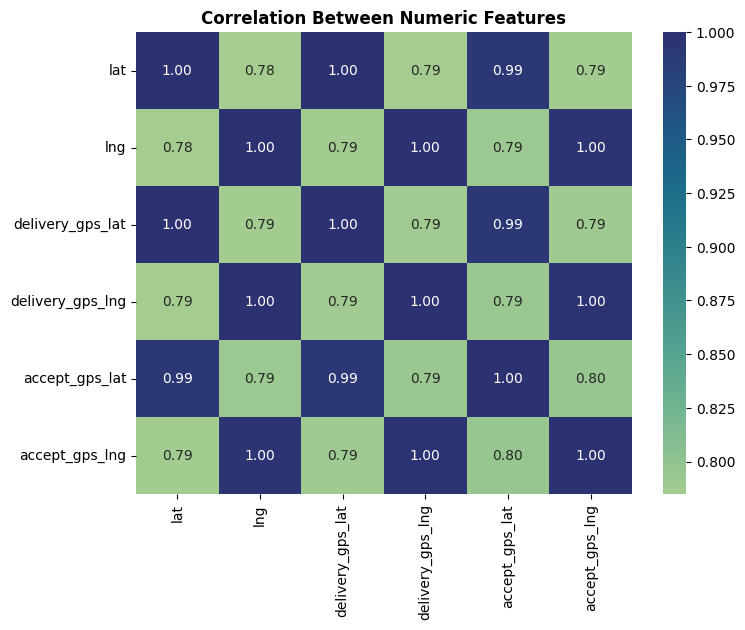

In [19]:
#CREATES a heatmap to show correlation between numeric features
num_cols = ['lat', 'lng', 'delivery_gps_lat', 'delivery_gps_lng',
            'accept_gps_lat', 'accept_gps_lng']
corr = sample_df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Between Numeric Features", fontweight='bold')
plt.show()

**This heatmap reveals an exceptionally high degree of multicollinearity among the geographical coordinates specifically latitude and longitude in the dataset indicating that most of these features are redundant.**

#####**6. Cardinality Check**

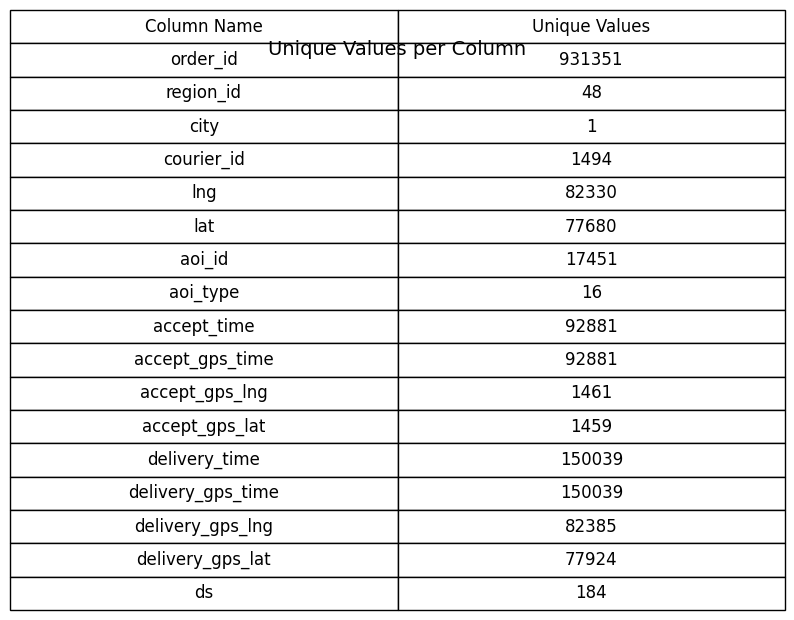

In [20]:
#CHECKS high or low cardinality between features
unique_counts = chitto_yatra_df.nunique()
df_counts = pd.DataFrame({
    "Column Name": unique_counts.index,
    "Unique Values": unique_counts.values
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(cellText=df_counts.values,
         colLabels=df_counts.columns,
         cellLoc='center',
         loc='center')

table.scale(1, 2)
table.set_fontsize(12)

plt.title("Unique Values per Column", y=1.3, fontsize=14)
plt.show()

**Since the city has low cardinality keeping it will not give us any meaningful pattern whereas order_id and courier has high cardinality and function as unique identidier rather than descriptive attributes. In addition to this, ds is not needed as it does not provide new information**

---
---

# **FEATURE SELECTION**

In [21]:
#REMOVES redundant columns from the dataframe
redundant_columns = ['lat', 'lng', 'accept_gps_time', 'delivery_gps_time']
chitto_yatra_df.drop(columns=redundant_columns, axis=1, inplace=True)

In [22]:
chitto_yatra_df

,order_id,region_id,city,courier_id,aoi_id,aoi_type,accept_time,accept_gps_lng,accept_gps_lat,delivery_time,delivery_gps_lng,delivery_gps_lat,ds
0,2031782,10,Chongqing,73,50,14,10-22 10:26:00,108.71826,30.95587,10-22 17:04:00,108.66361,30.96702,1022
1,4285071,10,Chongqing,3605,50,14,09-07 10:13:00,108.71791,30.95635,09-09 15:44:00,108.71644,30.90266,907
2,4056800,10,Chongqing,3605,50,14,06-26 09:49:00,108.71798,30.95635,06-27 16:03:00,108.71647,30.90251,626
3,3589481,10,Chongqing,3605,50,14,09-11 11:01:00,108.71823,30.95596,09-13 17:14:00,108.71650,30.90341,911
4,2752329,10,Chongqing,3605,50,14,10-01 09:52:00,108.71820,30.95598,10-01 18:30:00,108.71413,30.90397,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
931346,408723,166,Chongqing,4855,60054,1,10-27 08:36:00,106.52756,29.49760,10-27 12:30:00,106.50547,29.49880,1027
931347,3133674,166,Chongqing,4855,60054,1,10-25 09:24:00,106.52752,29.49765,10-25 12:53:00,106.48840,29.49507,1025
931348,4469852,166,Chongqing,4855,60054,1,10-24 14:11:00,106.52755,29.49764,10-24 16:39:00,106.48843,29.49484,1024
931349,2140790,166,Chongqing,4855,60054,1,10-29 15:24:00,106.52746,29.49751,10-29 18:08:00,106.48854,29.49509,1029


In [23]:
#REMOVES previously identified cardinality abnormalities column
irregular_cardinality_columns = ['city','order_id','ds','courier_id']
chitto_yatra_df.drop(columns=irregular_cardinality_columns, axis=1, inplace=True)

In [24]:
chitto_yatra_df

,region_id,aoi_id,aoi_type,accept_time,accept_gps_lng,accept_gps_lat,delivery_time,delivery_gps_lng,delivery_gps_lat
0,10,50,14,10-22 10:26:00,108.71826,30.95587,10-22 17:04:00,108.66361,30.96702
1,10,50,14,09-07 10:13:00,108.71791,30.95635,09-09 15:44:00,108.71644,30.90266
2,10,50,14,06-26 09:49:00,108.71798,30.95635,06-27 16:03:00,108.71647,30.90251
3,10,50,14,09-11 11:01:00,108.71823,30.95596,09-13 17:14:00,108.71650,30.90341
4,10,50,14,10-01 09:52:00,108.71820,30.95598,10-01 18:30:00,108.71413,30.90397
...,...,...,...,...,...,...,...,...,...
931346,166,60054,1,10-27 08:36:00,106.52756,29.49760,10-27 12:30:00,106.50547,29.49880
931347,166,60054,1,10-25 09:24:00,106.52752,29.49765,10-25 12:53:00,106.48840,29.49507
931348,166,60054,1,10-24 14:11:00,106.52755,29.49764,10-24 16:39:00,106.48843,29.49484
931349,166,60054,1,10-29 15:24:00,106.52746,29.49751,10-29 18:08:00,106.48854,29.49509


**After properly selecting required features the dataframe shape has dropped to 7 columns from 17.**

---
---

# **DATA TYPE CONVERSION**

In [25]:
#CHECKS data type proper alignment with its column
chitto_yatra_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931351 entries, 0 to 931350
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   region_id         931351 non-null  int64  
 1   aoi_id            931351 non-null  int64  
 2   aoi_type          931351 non-null  int64  
 3   accept_time       931351 non-null  object 
 4   accept_gps_lng    931351 non-null  float64
 5   accept_gps_lat    931351 non-null  float64
 6   delivery_time     931351 non-null  object 
 7   delivery_gps_lng  931351 non-null  float64
 8   delivery_gps_lat  931351 non-null  float64
dtypes: float64(4), int64(3), object(2)
memory usage: 64.0+ MB


In [26]:
#CONVERTS time columns to valid data type (Object to Date)
chitto_yatra_df['accept_time'] = pd.to_datetime('2025-' + chitto_yatra_df['accept_time'], format='%Y-%m-%d %H:%M:%S')
chitto_yatra_df['delivery_time'] = pd.to_datetime('2025-' + chitto_yatra_df['delivery_time'], format='%Y-%m-%d %H:%M:%S')

In [27]:
#SHOWS data type conversion format
date_cols = ['accept_time', 'delivery_time']

date_summary = pd.DataFrame({
    "Column Name": date_cols,
    "Data Type": [chitto_yatra_df[col].dtype for col in date_cols],
    "Datetime Format": ["YYYY-MM-DD HH:MM:SS"] * len(date_cols),
    "Year Used": ["2025"] * len(date_cols)
})

date_summary.style.hide(axis="index")

Column Name,Data Type,Datetime Format,Year Used
accept_time,datetime64[ns],YYYY-MM-DD HH:MM:SS,2025
delivery_time,datetime64[ns],YYYY-MM-DD HH:MM:SS,2025


In [28]:
#CHECKS whether the column data type has been successfully converted or not
chitto_yatra_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931351 entries, 0 to 931350
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   region_id         931351 non-null  int64         
 1   aoi_id            931351 non-null  int64         
 2   aoi_type          931351 non-null  int64         
 3   accept_time       931351 non-null  datetime64[ns]
 4   accept_gps_lng    931351 non-null  float64       
 5   accept_gps_lat    931351 non-null  float64       
 6   delivery_time     931351 non-null  datetime64[ns]
 7   delivery_gps_lng  931351 non-null  float64       
 8   delivery_gps_lat  931351 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(3)
memory usage: 64.0 MB


**The data type conversion of acceptance_time and delivery_time has been successfully done and now the columns are formatted in date : YYYY-MM-DD HH:MM:SS**

---
---

# **FEATURE ENGINEERING**

In [29]:
#EXTRACTS new features from the existing column: delivery_time and accept_time
chitto_yatra_df['accept_hour'] = chitto_yatra_df['accept_time'].dt.hour
chitto_yatra_df['accept_dayofweek'] = chitto_yatra_df['accept_time'].dt.dayofweek
chitto_yatra_df['delivery_duration_min'] = (chitto_yatra_df['delivery_time'] - chitto_yatra_df['accept_time']).dt.total_seconds() / 60

In [30]:
chitto_yatra_df

,region_id,aoi_id,aoi_type,accept_time,accept_gps_lng,accept_gps_lat,delivery_time,delivery_gps_lng,delivery_gps_lat,accept_hour,accept_dayofweek,delivery_duration_min
0,10,50,14,2025-10-22 10:26:00,108.71826,30.95587,2025-10-22 17:04:00,108.66361,30.96702,10,2,398.0
1,10,50,14,2025-09-07 10:13:00,108.71791,30.95635,2025-09-09 15:44:00,108.71644,30.90266,10,6,3211.0
2,10,50,14,2025-06-26 09:49:00,108.71798,30.95635,2025-06-27 16:03:00,108.71647,30.90251,9,3,1814.0
3,10,50,14,2025-09-11 11:01:00,108.71823,30.95596,2025-09-13 17:14:00,108.71650,30.90341,11,3,3253.0
4,10,50,14,2025-10-01 09:52:00,108.71820,30.95598,2025-10-01 18:30:00,108.71413,30.90397,9,2,518.0
...,...,...,...,...,...,...,...,...,...,...,...,...
931346,166,60054,1,2025-10-27 08:36:00,106.52756,29.49760,2025-10-27 12:30:00,106.50547,29.49880,8,0,234.0
931347,166,60054,1,2025-10-25 09:24:00,106.52752,29.49765,2025-10-25 12:53:00,106.48840,29.49507,9,5,209.0
931348,166,60054,1,2025-10-24 14:11:00,106.52755,29.49764,2025-10-24 16:39:00,106.48843,29.49484,14,4,148.0
931349,166,60054,1,2025-10-29 15:24:00,106.52746,29.49751,2025-10-29 18:08:00,106.48854,29.49509,15,2,164.0


In [31]:
#SHOWS metadata of extracted feature
new_extracted_cols = ['accept_hour', 'accept_dayofweek', 'delivery_duration_min']

df_new_info = pd.DataFrame({
    "Column Name": chitto_yatra_df[new_extracted_cols].columns,
    "Data Type": chitto_yatra_df[new_extracted_cols].dtypes.astype(str),
    "Non-Null Count": chitto_yatra_df[new_extracted_cols].notnull().sum()
})

df_new_info


,Column Name,Data Type,Non-Null Count
accept_hour,accept_hour,int32,931351
accept_dayofweek,accept_dayofweek,int32,931351
delivery_duration_min,delivery_duration_min,float64,931351


In [32]:
#DROPS accept_time and delivery_time column from dataframe
chitto_yatra_df = chitto_yatra_df.drop(columns=['accept_time', 'delivery_time'])

**After performing feature engineering, new columns like accept_hour, accept_dayofweek and delivery_duration_min has been created with numerical data type.**

---
---

# **Filtering for Q-Commerce**

In [33]:
#SELECTS only rows where delivery_duration_min is less or equal to 120
chitto_yatra_df = chitto_yatra_df[chitto_yatra_df['delivery_duration_min'] <= 120]

In [34]:
#SHOWS metadata of the newly filtered dataframe
filtered_shape = pd.DataFrame({
    "Dataset": ["chitto_yatra_df (Filtered)"],
    "Rows": [chitto_yatra_df.shape[0]],
    "Columns": [chitto_yatra_df.shape[1]]
})

In [35]:
filtered_shape

,Dataset,Rows,Columns
0,chitto_yatra_df (Filtered),366608,10


**Around only 366K rows meet the condition applied for filtration. The now finalized dataframe has shape (366608,10).**

----
----

# **SCALING**

In [36]:
#STANDARDIZE numeric features to have mean=0 and standard deviation=1
scaler = StandardScaler()
numeric_features = ['delivery_gps_lat', 'delivery_gps_lng', 'accept_gps_lat', 'accept_gps_lng']
X_scaled = scaler.fit_transform(chitto_yatra_df[numeric_features])

In [37]:
#SUMMARIZES scaled columns
summary_scaled = pd.DataFrame({
    "Feature": numeric_features,
    "Min (Scaled)": chitto_yatra_df[numeric_features].min().values,
    "Max (Scaled)": chitto_yatra_df[numeric_features].max().values,
    "Mean (Scaled)": chitto_yatra_df[numeric_features].mean().values,
    "Std (Scaled)": chitto_yatra_df[numeric_features].std().values
})

summary_scaled

,Feature,Min (Scaled),Max (Scaled),Mean (Scaled),Std (Scaled)
0,delivery_gps_lat,-0.00007,39.91199,29.594082,0.255881
1,delivery_gps_lng,-0.00004,120.06113,106.534517,0.663969
2,accept_gps_lat,29.04341,31.17579,29.593327,0.190695
3,accept_gps_lng,105.62791,120.03841,106.538355,0.262020


In [38]:
#STORES scaled features into a dataframe
scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)
scaled_df

,delivery_gps_lat,delivery_gps_lng,accept_gps_lat,accept_gps_lng
0,5.269122,3.291095,7.147352,8.318761
1,5.267793,3.296170,7.145726,8.319410
2,5.266855,3.293625,7.145569,8.319524
3,5.266581,3.293474,7.144835,8.319677
4,5.269512,3.290989,7.145569,8.319715
...,...,...,...,...
366603,-0.393666,-0.069773,-0.501832,-0.041391
366604,-0.388664,-0.070481,-0.501937,-0.041734
366605,-0.393041,-0.070918,-0.551388,0.020857
366606,-0.388000,-0.068749,-0.551807,0.020895


**The numeric required features like  devlivery/accept lng, lat, accept_hour and accept_dayofweek are scaled to have mean = 0 and std = 1 in order to improve model performance and ensure all features contribute equally making it spatio-temporal clustering.**

---
---

# **DIMENSIONALITY REDUCTION**

In [39]:
#SELECTS feature for PCA
X = scaled_df.values

In [40]:
#REMOVES outliers before feeding into PCA as it is outlier-sensitive
condition_outlier = (np.abs(zscore(X_scaled)) < 3).all(axis=1)
X_clean = X_scaled[condition_outlier]

In [41]:
#APPLY PCA to reduce features to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)
print("Explained variance ratio per component:", pca.explained_variance_ratio_)

Explained variance ratio per component: [0.70599902 0.28349087]


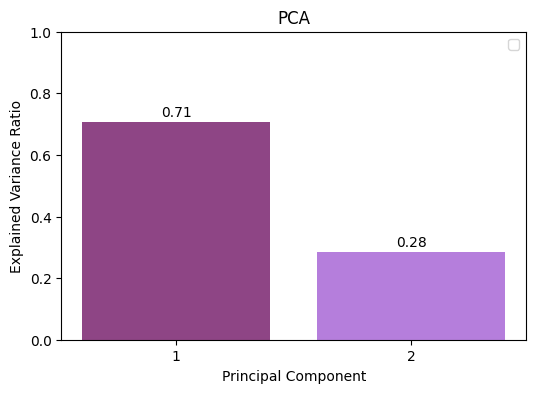

In [42]:
#SHOWS proportion of variance
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)
colors = ['#8E4585', '#B57EDC']

plt.figure(figsize=(6, 4))
bars = plt.bar(components, explained_variance, color=colors)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}",
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA')
plt.xticks(components)
plt.ylim(0, 1)
plt.legend()
plt.show()

**PCA was applied to the features lng, lat, accept_hour, accept_dayofweek and delivery duration time to reduce them to 2 principal components. This transformation retained approximately 99% of the original variance capturing the most significant patterns in the data while simplifying the feature space for visualization.**

---
---

# **CLUSTERING ALGORITHM**

**The algorithm used in this project are: KMeans, DBscan and Hierarchical (AgglomerativeClustering) to analyze each unsupervised model's behavior towards clustering the orders.**

# **KMEANS**

----

### **ELBOW METHOD TO FIND THE OPTIMAL K RANGES**

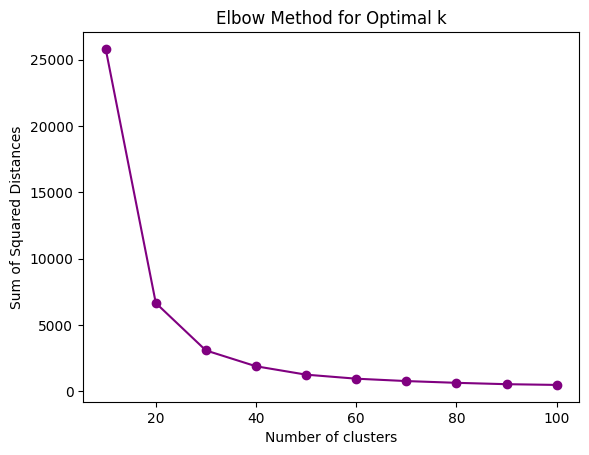

In [43]:
#DETERMINES the best optimal k using elbow method
wcss=[]
K_range = range(10, 101, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_clean)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o', color='purple')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal k')
plt.grid(False)
plt.show()

**From the visualization, the sweet spot for the optimal K ranges at 25-40 (Looking at the knee)**

In [44]:
#CALCULATES silhouette scores from the optimal k range
scores = {}
fine_range = range(20, 41)

sample_idx = np.random.choice(X_pca.shape[0], 10000, replace=False)
X_sample = X_clean[sample_idx]

for k in fine_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = calculate_silhouette_score(X_sample, labels)
    scores[k] = score
    print(f"k={k}: {score:.3f}")

k=20: 0.598
k=21: 0.595
k=22: 0.597
k=23: 0.610
k=24: 0.601
k=25: 0.611
k=26: 0.596
k=27: 0.599
k=28: 0.600
k=29: 0.616
k=30: 0.621
k=31: 0.606
k=32: 0.632
k=33: 0.618
k=34: 0.606
k=35: 0.618
k=36: 0.624
k=37: 0.635
k=38: 0.631
k=39: 0.653
k=40: 0.631


In [45]:
#SHOWS scores properly in a dataframe
scores_df = pd.DataFrame(list(scores.items()), columns=['K', 'Silhouette Score'])
scores_df = scores_df.sort_values('K').reset_index(drop=True)
scores_df

,K,Silhouette Score
0,20,0.597770
1,21,0.595423
2,22,0.597066
3,23,0.609868
4,24,0.601086
5,25,0.611245
6,26,0.595923
7,27,0.598964
8,28,0.599541
9,29,0.615995


**The optimal k with the highest silhouette score is seen to be around at 39. The optimal silhouette score of approximately 0.65 indicates excellent and meaningful cluster separation, which is rarely expected in real-world spatial delivery data where service zones naturally overlap.**

# **K-Means with Optimal K**

In [123]:
#FITS the model with final best K
final_k = 39
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_clean)

In [124]:
#CALCULATES Davies-Bouldin Index for the selected best K
dbi = calculate_DBI(X_clean, labels)
print("Davies-Bouldin Index:", dbi)

Davies-Bouldin Index: 0.4855749595793147


In [125]:
#CALCULATES calinski_harabasz_score for the selected best K
ch_score = calculate_calinski_harabasz(X_clean, labels)
print("Calinski-Harabasz Score:", ch_score)

Calinski-Harabasz Score: 1034491.8408481429


In [49]:
#STORES clusters assigned in a new column of df
chitto_yatra_df['cluster_kmeans'] = -1
chitto_yatra_df.loc[condition_outlier, 'cluster_kmeans'] = labels

**The clustering result is strong and reliable. The low DBI (0.49) indicates compact and well-separated clusters, while the high Calinski–Harabasz score confirms that the clusters are well-defined and distinct. Together, these metrics validate that the chosen number of clusters (k = 39) produces meaningful segmentation.**

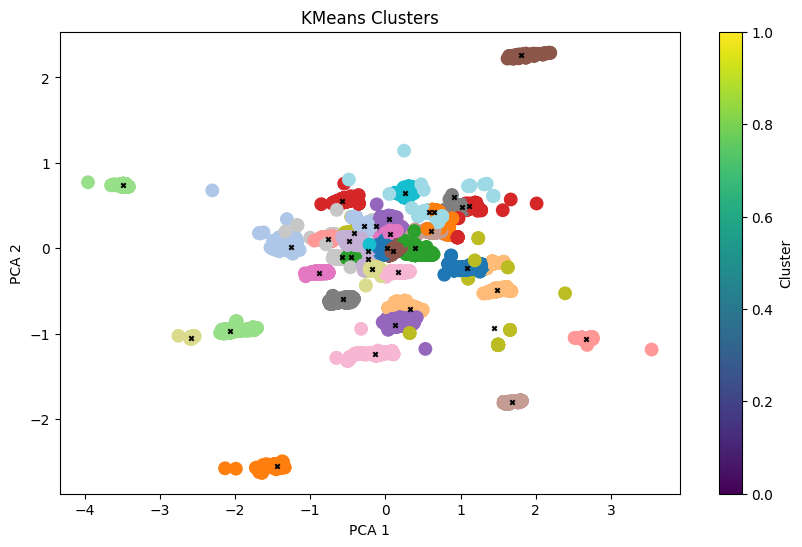

Original points: 357487
Points shown: 357487
Outliers hidden: 0


In [50]:
#PLOTS KMeans in the PCA components
clean_df_plot = chitto_yatra_df[condition_outlier].copy()
centers_scaled = kmeans.cluster_centers_
centers_pca = pca.transform(centers_scaled)
X_simple = X_pca
labels_simple = clean_df_plot['cluster_kmeans']
plt.figure(figsize=(10,6))
plt.scatter(X_simple[:, 0], X_simple[:, 1], c=labels_simple, cmap='tab20', s=80)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='x', s=10, c='black', label='Centers')
plt.title("KMeans Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label='Cluster')
plt.show()

print(f"Original points: {len(X_pca)}")
print(f"Points shown: {len(X_simple)}")
print(f"Outliers hidden: {len(X_pca) - len(X_simple)}")

**Outliers were removed during clustering because they distort PCA and KMeans. They are kept in the original dataset labeled -1 for future analysis**

## **K-Means Clustering pattern**

In [51]:
#GROUPS kmean clusters
cluster_pattern_kmeans = chitto_yatra_df.groupby('cluster_kmeans').agg({
    'accept_hour': 'mean',
    'accept_dayofweek': most_common_value,
    'delivery_duration_min': 'mean'
}).reset_index()

cluster_pattern_kmeans['count'] = chitto_yatra_df.groupby('cluster_kmeans').size().values

cluster_pattern_kmeans.head()

,cluster_kmeans,accept_hour,accept_dayofweek,delivery_duration_min,count
0,-1,9.367832,1,27.538866,9121
1,0,13.159949,0,70.795071,21832
2,1,8.898087,4,76.559157,2561
3,2,13.403798,0,72.095761,14745
4,3,12.621220,4,71.247719,11178


In [52]:
#CONVERTS the accept_hour avg to a period
cluster_pattern_readable_kmeans = cluster_pattern_kmeans.copy()

def time_range(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

cluster_pattern_readable_kmeans['time_range'] = cluster_pattern_readable_kmeans['accept_hour'].apply(time_range)

days = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 5:'Friday', 6:'Saturday'}
cluster_pattern_readable_kmeans['weekday'] = cluster_pattern_readable_kmeans['accept_dayofweek'].round().astype(int).map(days)

In [53]:
#RENAMES the created columns for proper viewing
cluster_pattern_readable_kmeans.columns = [
    'cluster',
    'avg_accept_hour',
    'dominant_day_num',
    'avg_delivery_time',
    'order_count',
    'time_range',
    'dominant_day'
]

cluster_pattern_readable_kmeans

,cluster,avg_accept_hour,dominant_day_num,avg_delivery_time,order_count,time_range,dominant_day
0,-1,9.367832,1,27.538866,9121,Morning,Monday
1,0,13.159949,0,70.795071,21832,Afternoon,Sunday
2,1,8.898087,4,76.559157,2561,Morning,Thursday
3,2,13.403798,0,72.095761,14745,Afternoon,Sunday
4,3,12.621220,4,71.247719,11178,Afternoon,Thursday
5,4,9.033924,6,80.676962,1975,Morning,Saturday
6,5,12.806738,1,71.361562,6530,Afternoon,Monday
7,6,12.906876,0,67.827326,14733,Afternoon,Sunday
8,7,13.092040,3,61.909851,10050,Afternoon,Wednesday
9,8,12.560461,1,68.237311,12570,Afternoon,Monday


In [54]:
#SHOWS KMeans Model Summary
cluster_sizes = pd.Series(labels).value_counts()
cluster_sizes.describe()

,count
count,40.000000
mean,8937.175000
std,7876.227523
min,42.000000
25%,2047.750000
50%,7452.000000
75%,13712.250000
max,31809.000000


**Most clusters are Afternoon-heavy, with average accept hours between 12 - 14, showing that the majority of orders are accepted after noon. These afternoon clusters also tend to have higher order counts (often 10,000 - 30,000 + orders) indicating peak demand periods. In contrast to this, Morning clusters (average accept hour around 8 - 10) generally have fewer orders suggesting lower demand earlier in the day.**

----
----

# **DBSCAN**

---

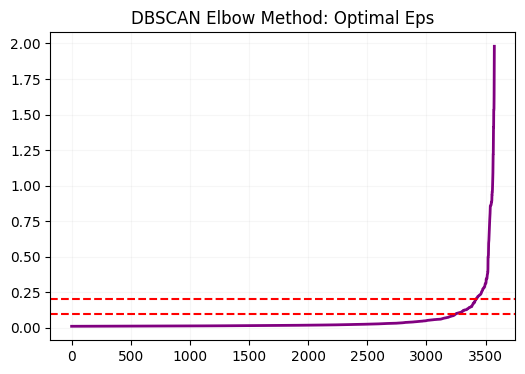

In [55]:
#PLOTS elbow to check the knee at zoomed top 1% data to see the optimal eps
minPts = 10

neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(X_clean)
distances, indices = neighbors_fit.kneighbors(X_clean)
k_distances = np.sort(distances[:, minPts-1])

tail_data = k_distances[int(len(k_distances) * 0.99):]

plt.figure(figsize=(6,4))
plt.plot(tail_data, linewidth=2, color='purple')
plt.title("DBSCAN Elbow Method: Optimal Eps")
plt.axhline(y=0.10, color='r', linestyle='--', label='Optimal Eps Range (min)')
plt.axhline(y=0.20, color='r', linestyle='--', label='Optimal Eps Range (max)')
plt.grid(True, alpha=0.1)
plt.show()

In [56]:
#CALCULATES silhouette score for each optimal eps range
eps_values = np.arange(0.10, 0.21, 0.01)
results_eps = []
sample_idx = np.random.choice(len(X_clean), 10000, replace=False)
X_sample = X_clean[sample_idx]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_sample)
    score = calculate_silhouette_score(X_sample, labels)
    results_eps.append((eps, score))

results_eps

[(np.float64(0.1), np.float64(0.6218829399969164)),
 (np.float64(0.11), np.float64(0.6048242437091517)),
 (np.float64(0.12), np.float64(0.604694954850772)),
 (np.float64(0.13), np.float64(0.5768580965818552)),
 (np.float64(0.13999999999999999), np.float64(0.5767272204209511)),
 (np.float64(0.14999999999999997), np.float64(0.5885589858949557)),
 (np.float64(0.15999999999999998), np.float64(0.5884896293127391)),
 (np.float64(0.16999999999999998), np.float64(0.46414540626065975)),
 (np.float64(0.17999999999999997), np.float64(0.33924581935615705)),
 (np.float64(0.18999999999999995), np.float64(0.33928264519147844)),
 (np.float64(0.19999999999999996), np.float64(0.24108781905880064))]

**The optimal eps is 0.10 because it gives the highest silhouette score (0.62).
For eps larger than 0.16, clustering quality drops sharply.**

---

## **DBSCAN with Optimal Eps**

In [58]:
#DBSCAN model train on the cleaned dataset
dbscan = DBSCAN(eps=0.10, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_sample)

In [59]:
#CALCULATES Davies-Bouldin Index for the selected best eps
dbi = calculate_DBI(X_sample, dbscan_labels)
print("Davies-Bouldin Index:", dbi)

Davies-Bouldin Index: 0.4147604937753078


In [60]:
#CALCULATES calinski_harabasz_score for the selected best eps
ch_score = calculate_calinski_harabasz(X_sample, dbscan_labels)
print("Calinski-Harabasz Score:", ch_score)

Calinski-Harabasz Score: 28063.671271502222


**The DBI score and CH score is both valid for the real-time dataset. However, due to the excess computational power needed, the dbscan is only trained on the sample data.**

In [73]:
#SHOWS the clusters and noise points in the dbscan
unique_labels = set(dbscan_labels)
if -1 in unique_labels:
    unique_labels.remove(-1)

num_clusters = len(unique_labels)
num_noise = np.sum(dbscan_labels == -1)

print(f"Number of clusters: {num_clusters}")
print(f"Number of noise points: {num_noise}")

Number of clusters: 35
Number of noise points: 421


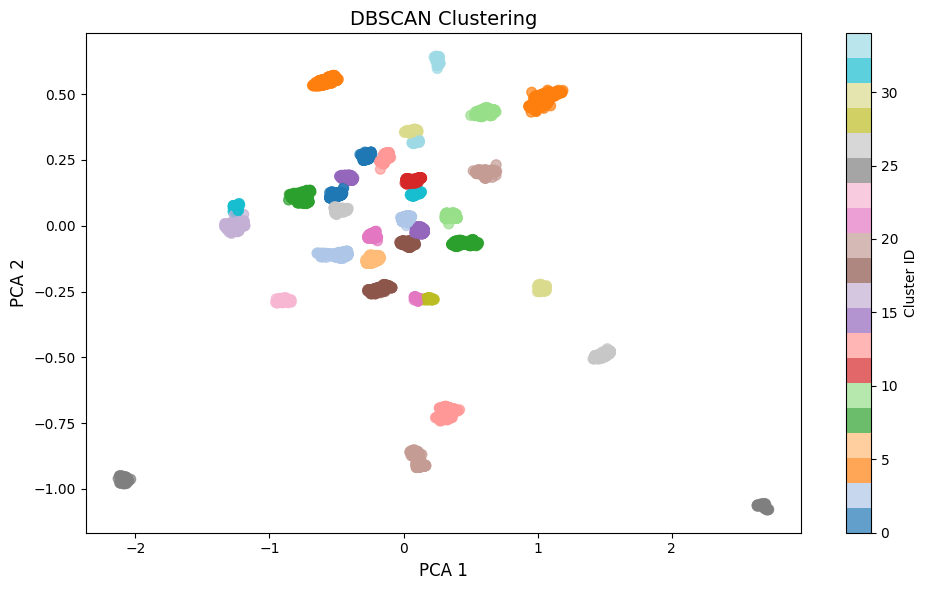

Total points: 10000
Noise points: 421
Points after removing noise: 9579


In [72]:
#PLOTS dbscan on the sampled data
plt.figure(figsize=(10, 6))
mask_clusters_dbscan = dbscan_labels != -1

plt.scatter(
    X_sample[mask_clusters_dbscan, 0],
    X_sample[mask_clusters_dbscan, 1],
    c=dbscan_labels[mask_clusters_dbscan],
    cmap='tab20',
    s=50,
    alpha=0.7
)

plt.title('DBSCAN Clustering', fontsize=14)
plt.xlabel('PCA 1', fontsize=12)
plt.ylabel('PCA 2', fontsize=12)
plt.colorbar(label='Cluster ID')
plt.tight_layout()
plt.show()

total_points = len(X_sample)
noise_points = (dbscan_labels == -1).sum()
clean_points = total_points - noise_points

print("Total points:", total_points)
print("Noise points:", noise_points)
print("Points after removing noise:", clean_points)


In [86]:
#SHOWS top labels and bottom labels
cluster_counts_dbscan = pd.Series(dbscan_labels).value_counts()
print(f"Top 10:\n{cluster_counts_dbscan.head(10)}")
print(f"Bottom 10:\n{cluster_counts_dbscan.tail(10)}")

Top 10:
 14    703
 11    568
 10    451
 2     440
 3     437
 1     424
-1     421
 21    414
 4     407
 19    404
Name: count, dtype: int64
Bottom 10:
31    66
23    66
28    59
25    50
22    48
30    41
33    40
24    39
34    38
32    33
Name: count, dtype: int64


In [89]:
#CONVERTS into df
cluster_counts_no_noise = cluster_counts_dbscan.drop(-1, errors='ignore')
top_5_df = cluster_counts_no_noise.head(5).reset_index()
top_5_df.columns = ['Cluster ID', 'Count']
bottom_5_df = cluster_counts_no_noise.tail(5).reset_index()
bottom_5_df.columns = ['Cluster ID', 'Count']
bottom_5_df

,Cluster ID,Count
0,30,41
1,33,40
2,24,39
3,34,38
4,32,33


In [88]:
top_5_df

,Cluster ID,Count
0,14,703
1,11,568
2,10,451
3,2,440
4,3,437


In [90]:
#SHOWS dbscan model summary
cluster_sizes = pd.Series(dbscan_labels).value_counts()
cluster_sizes.describe()

,count
count,36.000000
mean,277.777778
std,178.004191
min,33.000000
25%,66.000000
50%,355.000000
75%,404.750000
max,703.000000


---

## **DBscan Clustering pattern**

In [96]:
#GROUPS the dbscan data
dbscan_sample_df = chitto_yatra_df.sample(n=10000, random_state=42).copy()
dbscan_sample_df['cluster_dbscan'] = dbscan_labels

cluster_pattern_dbscan = dbscan_sample_df.groupby('cluster_dbscan').agg({
    'accept_hour': 'mean',
    'accept_dayofweek': most_common_value,
    'delivery_duration_min': 'mean'
}).reset_index()

cluster_pattern_dbscan['count'] = dbscan_sample_df.groupby('cluster_dbscan').size().values

cluster_pattern_dbscan.head()

,cluster_dbscan,accept_hour,accept_dayofweek,delivery_duration_min,count
0,-1,12.909739,5,68.168646,421
1,0,12.768844,0,68.396985,199
2,1,12.903302,1,67.929245,424
3,2,12.722727,6,69.900000,440
4,3,12.739130,4,70.558352,437


In [97]:
#MAPS the clustering pattern
cluster_pattern_readable_dbscan = cluster_pattern_dbscan.copy()
cluster_pattern_readable_dbscan['time_range'] = cluster_pattern_readable_dbscan['accept_hour'].apply(time_range)
cluster_pattern_readable_dbscan['weekday'] = cluster_pattern_readable_dbscan['accept_dayofweek'].round().astype(int).map(days)

In [98]:
#RENAMES the created columns for proper viewing
cluster_pattern_readable_dbscan.columns = [
    'cluster',
    'avg_accept_hour',
    'dominant_day_num',
    'avg_delivery_time',
    'order_count',
    'time_range',
    'dominant_day'
]

cluster_pattern_readable_dbscan

,cluster,avg_accept_hour,dominant_day_num,avg_delivery_time,order_count,time_range,dominant_day
0,-1,12.909739,5,68.168646,421,Afternoon,Friday
1,0,12.768844,0,68.396985,199,Afternoon,Sunday
2,1,12.903302,1,67.929245,424,Afternoon,Monday
3,2,12.722727,6,69.900000,440,Afternoon,Saturday
4,3,12.739130,4,70.558352,437,Afternoon,Thursday
5,4,12.997543,0,64.113022,407,Afternoon,Sunday
6,5,12.691919,1,69.391414,396,Afternoon,Monday
7,6,12.693370,4,68.267956,362,Afternoon,Thursday
8,7,12.558528,0,67.608696,299,Afternoon,Sunday
9,8,12.844687,4,68.000000,367,Afternoon,Thursday


**The DBSCAN clustering results show that most orders are accepted in the Afternoon (around 12 - 13 hours) with an average delivery time of 65 - 70 minutes. The algorithm formed many small clusters, indicating that the data is highly dense and there are no strong separations between customer behaviors. The noise cluster (-1) contains 421 orders suggesting that only a small portion of orders are significantly different from the main patterns**

----
----

 # **Hierarchical Clustering (Agglomerative)**

---

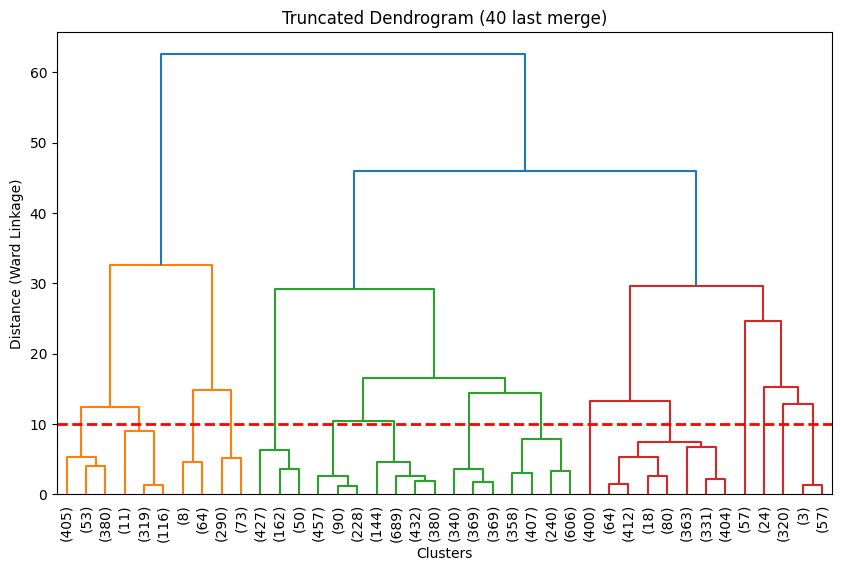

In [103]:
#PLOTS dendogram
indices = np.random.choice(X_pca.shape[0], 10000, replace=False)
X_sample = X_pca[indices]
Z = linkage(X_sample, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=40,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=10.
)

plt.axhline(y=10, color='red', linestyle='--', lw=2)

plt.title('Truncated Dendrogram (40 last merge)')
plt.xlabel('Clusters')
plt.ylabel('Distance (Ward Linkage)')

plt.show()


In [108]:
#CHECKS the clustered number
t_value = 10
labels = fcluster(Z, t=t_value, criterion='distance')
num_clusters = len(np.unique(labels))

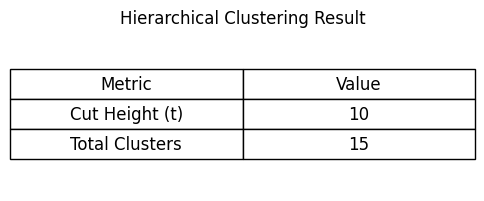

In [109]:
#FINDS the number of cluster with the help of k from dendrogram
table_data = [
    ["Cut Height (t)", t_value],
    ["Total Clusters", num_clusters]
]

fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=["Metric", "Value"],
    loc='center',
    cellLoc='center'
)

table.scale(1, 1.8)
table.auto_set_font_size(False)
table.set_fontsize(12)

plt.title("Hierarchical Clustering Result", pad=10)
plt.show()

# **HIERARCHICAL With Optimal K**

In [112]:
#Trains the hierarchical model
k = 15
hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
labels_hc = hc.fit_predict(X_sample)

In [113]:
#CALCULATES silhouette score for the best k from dendrogram
hc_sil = silhouette_score(X_sample, labels_hc)
print("Silhouette Score:", hc_sil)

Silhouette Score: 0.5762612570046085


In [114]:
#CALCULATES Davies Bouldin Score for the best k from dendrogram
hc_dbi = davies_bouldin_score(X_sample, labels_hc)
print("DBI Score:", hc_dbi)

DBI Score: 0.43139432575477


In [115]:
#CALCULATES  for the best k from dendrogram
hc_ch = calinski_harabasz_score(X_sample, labels_hc)
print("CH score:", hc_ch)

CH score: 14674.1437926111


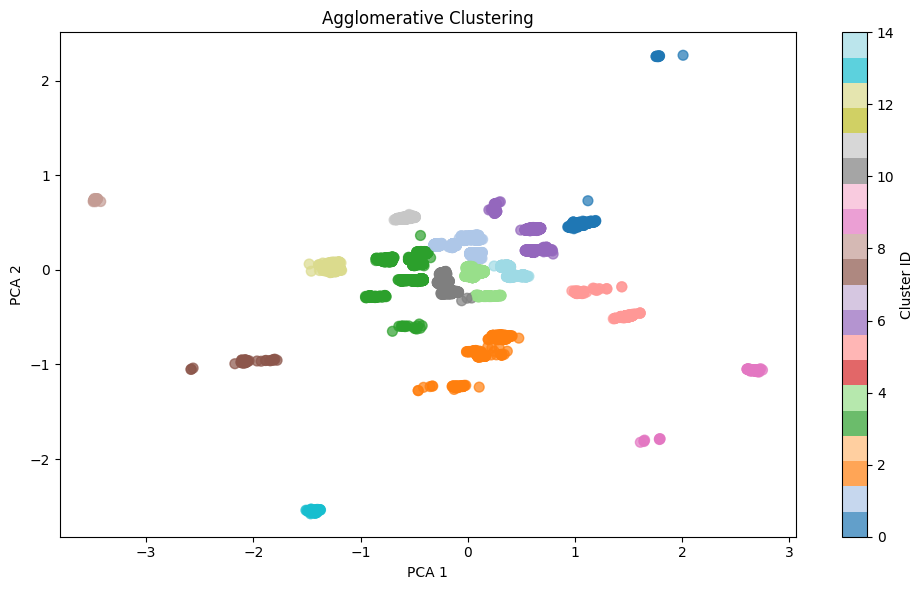

In [118]:
#PLOTS the hierarchical clusterings in the PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_sample[:, 0],
    X_sample[:, 1],
    c=labels_hc,
    cmap='tab20',
    s=50,
    alpha=0.7
)
plt.title('Agglomerative Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.show()

In [120]:
#GROUPS the hierarchical data
hc_sample_df = chitto_yatra_df.sample(n=10000, random_state=42).copy()
hc_sample_df['cluster_hc'] = labels_hc

cluster_pattern_hc = hc_sample_df.groupby('cluster_hc').agg({
    'accept_hour': 'mean',
    'accept_dayofweek': most_common_value,
    'delivery_duration_min': 'mean'
}).reset_index()

cluster_pattern_hc['count'] = hc_sample_df.groupby('cluster_hc').size().values

cluster_pattern_hc.head()

,cluster_hc,accept_hour,accept_dayofweek,delivery_duration_min,count
0,0,12.739910,1,69.695067,446
1,1,12.789572,1,68.198634,1611
2,2,12.785603,6,66.993740,639
3,3,12.852273,0,67.424043,1672
4,4,12.851672,0,67.479635,1645


In [121]:
#MAPS the clustering pattern
cluster_pattern_readable_hc = cluster_pattern_hc.copy()
cluster_pattern_readable_hc['time_range'] = cluster_pattern_readable_hc['accept_hour'].apply(time_range)
cluster_pattern_readable_hc['weekday'] = cluster_pattern_readable_hc['accept_dayofweek'].round().astype(int).map(days)

In [122]:
#RENAMES the created columns for proper viewing
cluster_pattern_readable_hc.columns = [
    'cluster',
    'avg_accept_hour',
    'dominant_day_num',
    'avg_delivery_time',
    'order_count',
    'time_range',
    'dominant_day'
]

cluster_pattern_readable_hc

,cluster,avg_accept_hour,dominant_day_num,avg_delivery_time,order_count,time_range,dominant_day
0,0,12.739910,1,69.695067,446,Afternoon,Monday
1,1,12.789572,1,68.198634,1611,Afternoon,Monday
2,2,12.785603,6,66.993740,639,Afternoon,Saturday
3,3,12.852273,0,67.424043,1672,Afternoon,Sunday
4,4,12.851672,0,67.479635,1645,Afternoon,Sunday
5,5,12.878788,2,68.151515,363,Afternoon,Tuesday
6,6,12.713604,1,66.854415,838,Afternoon,Monday
7,7,13.250000,2,62.800000,60,Afternoon,Tuesday
8,8,12.958333,4,68.125000,24,Afternoon,Thursday
9,9,12.861111,2,65.041667,72,Afternoon,Tuesday


**The clustered made by the hierarchical algorithm is mainly clustered by day-of-week patterns, especially Monday and Sunday, while delivery time remains consistent.**

# Thank you !!! :)